# Point-Probe Elastography — Designing an Identifiable Inversion


## Outline

1. Why redesign the experiment — rank deficiency of shape-only fitting
2. The design tool — sensitivity singular-value spectra
3. Setup — imports and output directory
4. Build the shell grid and elastic field
5. Experiment design: pre-tensioned membrane + point probes
6. Measure the identifiability spectrum (drape vs point sweep)
7. Hidden target field and probe measurements
8. The inversion loop
9. Recovery quality and convergence
10. Recap


## 1. Why redesign the experiment

The companion demo (`elastic_material_optimization_demo`) fits a
single gravity-sag shape.  That works for a *large-scale, monotone*
stiffness pattern, but the observation operator is fundamentally
rank-deficient:

- a hanging drape is geometry-dominated, so a **uniform scaling** of
  $E_m$ barely changes the equilibrium shape (scale null space);
- a taut membrane is the mirror image: tension statics determine the
  deflection, so the **spatial pattern** of $E_m$ is nearly invisible;
- localized interior soft regions alias with neighbouring stiffness
  and routinely trap the optimizer in wrong-pattern local minima.

The cure is not a better optimizer — it is a better experiment.
A transverse **point probe** responds mostly to the stiffness *near
the probe*, so sweeping a probe over the surface produces an
observation operator that is close to diagonally dominant in the
element stiffnesses.  This is the static analogue of elastography /
indentation mapping.  A known probe force also carries physical
units, which breaks the dimensionless scale degeneracy of
shape-only data.


## 2. The design tool — sensitivity spectra

Identifiability can be *measured before any inversion*.  Build the
relative sensitivity matrix by finite differences at the prior
field $\mathbf b_0$,

$$
S_{:,e} = \frac{\partial\, \mathbf x_\mathrm{surf}}
{\partial \ln E_{m,e}},
$$

one forward solve pair per element, and look at its singular
values.  The effective rank (number of $\sigma_i$ above the
measurement noise floor) bounds how many stiffness degrees of
freedom *any* inversion can recover; the tail conditioning
$\sigma_{50}/\sigma_1$ controls bias amplification.  Section 6
computes these spectra for the gravity-drape design and the
point-sweep design on the same mesh.


## 3. Setup — imports and output directory


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypgo as pgo
import pypgo.energy as pe
import pypgo.fem as pf
import pypgo.solver as ps
import torch

PACKAGE_ROOT = Path(pgo.__file__).resolve().parent.parent
OUTPUT_DIR = PACKAGE_ROOT / "examples" / "outputs" / "elastic_pointprobe_inversion"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=5, suppress=True)
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)


## 4. Build the shell grid and elastic field

Same Koiter StVK shell grid as the companion demo: five elastic
channels per triangle, of which only $E_m$ (channel 0) is treated
as unknown.


In [2]:
nx = ny = 5

def vertex_id(i, j):
    return i * (ny + 1) + j

vertices = np.array(
    [[i / nx, j / ny, 0.0] for i in range(nx + 1) for j in range(ny + 1)],
    dtype=np.float64,
)
triangles = []
for i in range(nx):
    for j in range(ny):
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j), vertex_id(i + 1, j + 1)])
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j + 1), vertex_id(i, j + 1)])
triangles = np.asarray(triangles, dtype=np.int64)
surface = pgo.mesh.TriMeshData(vertices, triangles)

shell_mat = pf.KoiterStVKShellMaterial(
    thickness=1.0e-3,
    E_membrane=2.0e4,
    nu_membrane=0.35,
)
sim = pf.SimulationMesh.create_shell(surface, shell_mat)

base_elastic_row = np.array([2.0e4, 0.35, 1.0e4, 0.25, 1.0e-3], dtype=np.float64)
initial_elastic = np.tile(base_elastic_row, (triangles.shape[0], 1))
plastic_values = np.ones((triangles.shape[0], 1), dtype=np.float64)

energy = pf.deformation_energy(
    sim,
    elastic=pf.KoiterStVK(),
    elastic_field=pf.ElementwiseField(values=initial_elastic),
    plastic=pf.ShellPlasticity(dofs=1),
    plastic_field=pf.ElementwiseField(values=plastic_values),
    formulation=pf.KoiterShell(),
    options=pf.DeformationOptions(enforce_spd=False, enable_material_max_step=False),
)
num_dofs = energy.num_dofs
n_elem = triangles.shape[0]
centers = vertices[triangles].mean(axis=1)

print("shell grid:", nx, "x", ny, "->", surface.num_vertices, "vertices,",
      surface.num_elements, "triangles")
print("elastic field shape:", energy.elastic_field.values.shape,
      "| unknowns: E_membrane per element =", n_elem)


[2026-06-11 12:15:42.050] [info] [deformationModelManager.cpp:248] Initializing element models (manager path)...
shell grid: 5 x 5 -> 36 vertices, 50 triangles
elastic field shape: (50, 5) | unknowns: E_membrane per element = 50
[2026-06-11 12:15:42.050] [info] [deformationModelAssembler.cpp:227] Assembler parameter channels:5,1 local:5,1


## 5. Experiment design: pre-tensioned membrane + point probes

- Both $y$-edges are clamped and the $y{=}1$ edge is pre-displaced
  by $+5\%$ in $y$.  The all-tension state keeps the equilibrium
  **unique** (a slack sheet clamped on two edges is multistable —
  compressed regions admit several wrinkling branches, which
  silently corrupts warm-started inner solves).
- A transverse point force of known magnitude ($0.2$ N) is applied
  at three interior probe vertices, one equilibrium solve each.
- The probe force is independent of $\mathbf b$, so the layer needs
  no `external_load` correction term.


In [3]:
pre_stretch = 0.05
probe_force = 0.2
probe_points = [(1, 2), (2, 3), (4, 2)]

is_top = np.isclose(vertices[:, 1], 1.0)
is_bot = np.isclose(vertices[:, 1], 0.0)

def make_bc(top_only, stretch=0.0):
    fv = np.flatnonzero(is_top if top_only else (is_top | is_bot)).astype(np.int64)
    fd = (3 * fv[:, None] + np.arange(3, dtype=np.int64)).ravel()
    fx = np.zeros(fd.size, dtype=np.float64)
    for k, v in enumerate(fv):
        if is_top[v]:
            fx[3 * k + 1] = stretch
    return fd, fx

taut_bc = make_bc(top_only=False, stretch=pre_stretch)
drape_bc = make_bc(top_only=True)   # only for the spectrum comparison

def point_force(i, j, fz):
    f = np.zeros(num_dofs, dtype=np.float64)
    f[3 * vertex_id(i, j) + 2] = fz
    return f

probe_forces = [point_force(i, j, -probe_force) for i, j in probe_points]

def objective_for_force(f):
    return pe.EnergySet([(energy, 1.0), (pe.LinearEnergy(-f), 1.0)])

def solve_case(elastic_values, objective_fn, fixed_dofs, fixed_values):
    energy.set_elastic_values(elastic_values)
    problem = ps.OptimizationProblem(objective=objective_fn())
    problem.fix_variables(fixed_dofs.tolist(), fixed_values, num_dofs=num_dofs)
    result = ps.NewtonOptimizer(
        max_iterations=200,
        gradient_tolerance=1e-9,
        damping=ps.FixedDamping(),
        line_search=ps.Backtrack(),
    ).solve(problem, energy.zero_state())
    if not result.converged:
        print("solve warning:", result.status.name,
              "grad:", result.final_gradient_max_norm)
    return vertices + result.x.reshape((-1, 3))

print("probe vertices:", [vertex_id(i, j) for i, j in probe_points],
      "| pre-stretch:", pre_stretch, "| probe force:", probe_force, "N")


probe vertices: [8, 15, 26] | pre-stretch: 0.05 | probe force: 0.2 N


## 6. Measure the identifiability spectrum

One central finite-difference pair per element and per design
($2\times 2\times 50$ Newton solves, a few milliseconds each).
The point-sweep design should be close to full rank, the drape
far from it.


design             sigma_1  sig50/sig1  rank@1%
[2026-06-11 12:15:42.091] [info] [NewtonSolver.cpp:416] Newton solve time: 0.017125
[2026-06-11 12:15:42.103] [info] [NewtonSolver.cpp:416] Newton solve time: 0.011201
[2026-06-11 12:15:42.112] [info] [NewtonSolver.cpp:416] Newton solve time: 0.008389
[2026-06-11 12:15:42.122] [info] [NewtonSolver.cpp:416] Newton solve time: 0.00925
[2026-06-11 12:15:42.130] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007042
[2026-06-11 12:15:42.138] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007734
[2026-06-11 12:15:42.147] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007689
[2026-06-11 12:15:42.155] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007642
[2026-06-11 12:15:42.163] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007198
[2026-06-11 12:15:42.170] [info] [NewtonSolver.cpp:416] Newton solve time: 0.006633
[2026-06-11 12:15:42.177] [info] [NewtonSolver.cpp:416] Newton solve time: 0.006541
[2026-06-11 12:15:42.185] [in

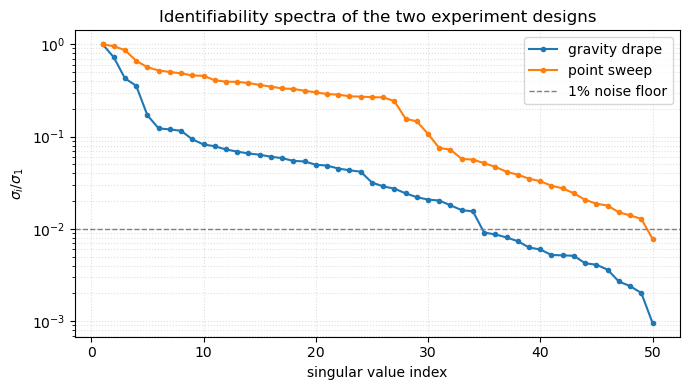

In [4]:
# gravity load for the drape design (companion-demo configuration)
mass_field = pf.ShellDensityElasticThickness(
    density=1000.0, parameter_field=energy.elastic_field, channel=4)
gravity_drape = pf.SelfWeightGravity(
    formulation=pf.KoiterShell(), sim_mesh=sim,
    mass_field=mass_field,
    acceleration=np.array([0.0, 0.0, -20.0], dtype=np.float64))

def objective_gravity():
    return pe.EnergySet([(energy, 1.0),
                         (pe.LinearEnergy(-gravity_drape.force()), 1.0)])

rel_step = 0.01

def sensitivity(case_list):
    # rows: stacked surface coordinates of every case
    # cols: d x / d ln(Em_e) per element
    blocks = []
    for objective_fn, fd, fx in case_list:
        S = np.zeros((3 * vertices.shape[0], n_elem))
        for e in range(n_elem):
            up = initial_elastic.copy(); up[e, 0] *= 1.0 + rel_step
            dn = initial_elastic.copy(); dn[e, 0] *= 1.0 - rel_step
            xp = solve_case(up, objective_fn, fd, fx).ravel()
            xm = solve_case(dn, objective_fn, fd, fx).ravel()
            S[:, e] = (xp - xm) / (2.0 * rel_step)
        blocks.append(S)
    energy.set_elastic_values(initial_elastic)
    return np.vstack(blocks)

designs = {
    "gravity drape": [(objective_gravity, *drape_bc)],
    "point sweep": [(lambda f=f: objective_for_force(f), *taut_bc)
                    for f in probe_forces],
}

spectra = {}
print(f"{'design':16s} {'sigma_1':>9s} {'sig50/sig1':>11s} {'rank@1%':>8s}")
for name, case_list in designs.items():
    S = sensitivity(case_list)
    sv = np.linalg.svd(S, compute_uv=False)
    spectra[name] = sv
    rank = int(np.sum(sv > 0.01 * sv[0]))
    print(f"{name:16s} {sv[0]:9.4f} {sv[-1] / sv[0]:11.2e} {rank:8d}")

fig, ax = plt.subplots(figsize=(7, 4))
for name, sv in spectra.items():
    ax.semilogy(np.arange(1, sv.size + 1), sv / sv[0], marker="o", ms=3,
                lw=1.5, label=name)
ax.axhline(0.01, color="gray", ls="--", lw=1.0, label="1% noise floor")
ax.set_xlabel("singular value index")
ax.set_ylabel(r"$\sigma_i / \sigma_1$")
ax.set_title("Identifiability spectra of the two experiment designs")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend()
fig.tight_layout()
plt.show()


## 7. Hidden target field and probe measurements

The hidden field is the *hard* case for shape fitting: a localized
Gaussian soft band at mid-span on a stiff background.  In the
drape demo this pattern is unrecoverable (the optimizer converges
to wrong-pattern local minima); here every probe sees it directly.


In [5]:
midspan = np.exp(-((centers[:, 1] - 0.5) / 0.25) ** 2)
center_band = np.exp(-((centers[:, 0] - 0.5) / 0.75) ** 2)
softness = midspan * center_band
target_elastic = initial_elastic.copy()
target_elastic[:, 0] *= 1.0 - 0.9 * softness
target_Em = target_elastic[:, 0]

target_surfaces = [
    solve_case(target_elastic, lambda f=f: objective_for_force(f), *taut_bc)
    for f in probe_forces
]
energy.set_elastic_values(initial_elastic)

print("target E_membrane:  min={:.0f}  max={:.0f}  mean={:.0f}".format(
    target_Em.min(), target_Em.max(), target_Em.mean()))
for (i, j), t in zip(probe_points, target_surfaces):
    print(f"  probe at vertex ({i},{j}): max |z| deflection = "
          f"{np.abs(t[:, 2]).max():.4f}")


[2026-06-11 12:15:44.679] [info] [NewtonSolver.cpp:416] Newton solve time: 0.018328
[2026-06-11 12:15:44.693] [info] [NewtonSolver.cpp:416] Newton solve time: 0.012777
[2026-06-11 12:15:44.704] [info] [NewtonSolver.cpp:416] Newton solve time: 0.008716
target E_membrane:  min=2352  max=19361  mean=13067
  probe at vertex (1,2): max |z| deflection = 0.0491
  probe at vertex (2,3): max |z| deflection = 0.0522
  probe at vertex (4,2): max |z| deflection = 0.0497


## 8. The inversion loop

Same differentiable-equilibrium machinery as the companion demo,
with three layers (one per probe) sharing one elastic field:

1. `em_net(xy)` predicts per-element $E_m$ (log-space output, so
   the 12-fold dynamic range of the target stays well inside the
   network's comfortable output range).
2. One equilibrium solve per probe; shape losses are summed.
3. Weight decay is tiny ($10^{-6}$) — with informative data no
   strong prior is needed, and a large value can collapse the
   network to a constant before the pattern signal is absorbed.
4. No mean-stiffness anchor: the probe force magnitude already
   pins the absolute scale.


In [6]:
def make_layer(f):
    return pgo.fem.ElasticStaticEquilibriumLayer(
        energy=energy,
        objective_energy=objective_for_force(f),
        fixed_dofs=taut_bc[0],
        fixed_values=taut_bc[1],
        surface_vertices=vertices,
        surface_vertex_ids=np.arange(vertices.shape[0], dtype=np.int64),
        inner_optimizer=ps.NewtonOptimizer(
            max_iterations=200,
            gradient_tolerance=1e-9,
            damping=ps.FixedDamping(),
            line_search=ps.Backtrack(),
        ),
    )

probe_layers = [make_layer(f) for f in probe_forces]
targets_torch = [torch.as_tensor(t, dtype=torch.float64) for t in target_surfaces]

b0 = energy.elastic_field.values.ravel().copy()
b0_torch = torch.as_tensor(b0, dtype=torch.float64)
xy = torch.as_tensor(centers[:, :2], dtype=torch.float64)
l2_weight = 1.0e-6

class EmNet(torch.nn.Module):
    # Tiny MLP: (x, y) -> E_membrane, log-space output centered
    # at 12 kPa so a zero-initialized head starts uniform.
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 8), torch.nn.Tanh(),
            torch.nn.Linear(8, 8), torch.nn.Tanh(),
            torch.nn.Linear(8, 1),
        )
        with torch.no_grad():
            self.net[-1].bias.zero_()
            self.net[-1].weight.zero_()

    def forward(self, xy):
        return 12000.0 * torch.exp(self.net(xy).squeeze(-1))

em_net = EmNet().to(torch.float64)
num_outer_steps = 600
outer_optimizer = torch.optim.Adam(em_net.parameters(), lr=0.03)
lr_schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
    outer_optimizer, T_max=num_outer_steps, eta_min=1e-3)

def build_param(Em):
    p = b0_torch.clone()
    p[0::5] = Em
    return p

history = []
best_value = np.inf
best_state = {k: v.detach().clone() for k, v in em_net.state_dict().items()}

for iteration in range(num_outer_steps):
    outer_optimizer.zero_grad()
    Em = em_net(xy)
    param = build_param(Em)
    shape_loss = 0.0
    probe_errors = []
    for layer, tgt in zip(probe_layers, targets_torch):
        solved = layer(param)
        residual = solved - tgt
        shape_loss = shape_loss + 0.5 * torch.sum(residual ** 2)
        probe_errors.append(float(torch.linalg.norm(residual.detach().ravel())))
    wd = l2_weight * sum((p ** 2).sum() for p in em_net.parameters())
    loss = shape_loss + wd
    loss.backward()

    value = float(loss.detach())
    if value < best_value:
        best_value = value
        best_state = {k: v.detach().clone() for k, v in em_net.state_dict().items()}
    outer_optimizer.step()
    lr_schedule.step()
    history.append((value, float(np.linalg.norm(probe_errors))))
    if iteration < 3 or (iteration + 1) % 50 == 0:
        with torch.no_grad():
            print(f"  step {iteration+1:3d}  loss={value:.8f}  "
                  f"probe errs={['%.4f' % e for e in probe_errors]}  "
                  f"Em=[{float(Em.min()):.0f}, {float(Em.max()):.0f}]  "
                  f"mean={float(Em.mean()):.0f}")

print(f"\nbest objective over {num_outer_steps} steps: {best_value:.8f}")


[2026-06-11 12:15:45.738] [info] [NewtonSolver.cpp:416] Newton solve time: 0.005217
[2026-06-11 12:15:45.747] [info] [NewtonSolver.cpp:416] Newton solve time: 0.004257
[2026-06-11 12:15:45.753] [info] [NewtonSolver.cpp:416] Newton solve time: 0.004579
  step   1  loss=0.00101038  probe errs=['0.0244', '0.0284', '0.0246']  Em=[12000, 12000]  mean=12000
[2026-06-11 12:15:45.789] [info] [NewtonSolver.cpp:416] Newton solve time: 0.00076
[2026-06-11 12:15:45.790] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000974
[2026-06-11 12:15:45.792] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000799
  step   2  loss=0.00094147  probe errs=['0.0240', '0.0267', '0.0242']  Em=[10896, 11291]  mean=11086
[2026-06-11 12:15:45.799] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000834
[2026-06-11 12:15:45.800] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000779
[2026-06-11 12:15:45.802] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000804
  step   3  loss=0.00094357  probe errs=[

## 9. Recovery quality and convergence


In [7]:
em_net.load_state_dict(best_state)
with torch.no_grad():
    Em_best = em_net(xy).numpy()

Em_diff = Em_best - target_Em
Em_relerr = np.abs(Em_diff) / np.maximum(np.abs(target_Em), 1.0)
corr = np.corrcoef(target_Em, Em_best)[0, 1]

print("recovered vs prescribed E_membrane — first 12 elements:")
print(f"{'elem':>4s}  {'target':>8s}  {'recovered':>10s}  {'delta':>10s}")
for i in range(min(12, n_elem)):
    print(f"{i:4d}  {target_Em[i]:8.1f}  {Em_best[i]:10.1f}  {Em_diff[i]:+10.1f}")
print()
print("E_membrane recovery:")
print(f"  target:               min={target_Em.min():.0f}  max={target_Em.max():.0f}  "
      f"mean={target_Em.mean():.0f}")
print(f"  recovered:            min={Em_best.min():.0f}  max={Em_best.max():.0f}  "
      f"mean={Em_best.mean():.0f}")
print(f"  absolute-scale error: "
      f"{abs(Em_best.mean() - target_Em.mean()) / target_Em.mean() * 100:.1f}% "
      f"(was >50% for every shape-only design)")
print(f"  correlation r:        {corr:.4f}")
print(f"  mean relative error:  {Em_relerr.mean():.4f}")
print(f"  max relative error:   {Em_relerr.max():.4f}")

weight_path = OUTPUT_DIR / "pointprobe_recovered_field.npz"
np.savez(
    weight_path,
    vertices=vertices,
    triangles=triangles,
    initial_elastic=initial_elastic,
    target_elastic=target_elastic,
    recovered_Em=Em_best,
    probe_points=np.asarray(probe_points),
    target_surfaces=np.stack(target_surfaces),
)
print("saved ->", weight_path)


recovered vs prescribed E_membrane — first 12 elements:
elem    target   recovered       delta
   0   19297.5     25671.0     +6373.6
   1   18500.0     19448.4      +948.4
   2   14068.7      9948.8     -4119.9
   3   11734.4      7431.9     -4302.5
   4    6076.5      5350.0      -726.4
   5    7336.0      5311.2     -2024.7
   6   10912.4      7050.9     -3861.5
   7   14605.2      9018.4     -5586.8
   8   18350.9     17408.5      -942.4
   9   19361.0     24751.8     +5390.7
  10   19150.8     25457.3     +6306.5
  11   18098.8     19233.9     +1135.1

E_membrane recovery:
  target:               min=2352  max=19361  mean=13067
  recovered:            min=5311  max=28167  mean=13394
  absolute-scale error: 2.5% (was >50% for every shape-only design)
  correlation r:        0.8881
  mean relative error:  0.2944
  max relative error:   1.2973
saved -> /Users/jinceyang/Desktop/codebase/libpgo/examples/outputs/elastic_pointprobe_inversion/pointprobe_recovered_field.npz


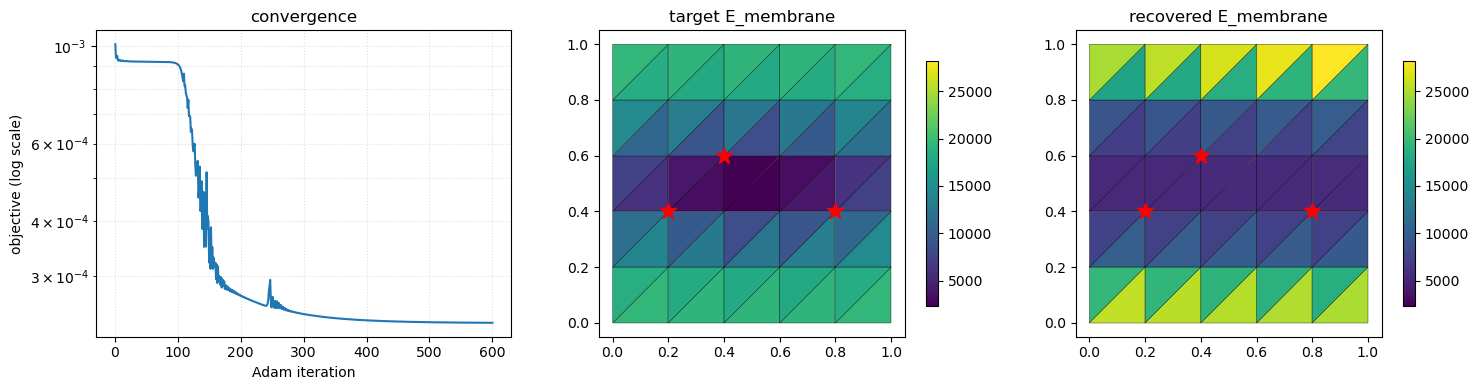

In [8]:
objective_hist = np.array([h[0] for h in history])
steps = np.arange(1, len(history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(steps, objective_hist, color="tab:blue", lw=1.5)
axes[0].set_xlabel("Adam iteration")
axes[0].set_ylabel("objective (log scale)")
axes[0].set_title("convergence")
axes[0].grid(True, which="both", ls=":", alpha=0.4)

def plot_field(ax, values, title, vmin, vmax):
    tri = ax.tripcolor(vertices[:, 0], vertices[:, 1], triangles,
                       facecolors=values, edgecolors="k", linewidth=0.25,
                       cmap="viridis", shading="flat", vmin=vmin, vmax=vmax)
    ax.set_aspect("equal")
    ax.set_title(title)
    for (i, j) in probe_points:
        ax.plot(i / nx, j / ny, "r*", ms=12)
    plt.colorbar(tri, ax=ax, shrink=0.8)

vmin = min(target_Em.min(), Em_best.min())
vmax = max(target_Em.max(), Em_best.max())
plot_field(axes[1], target_Em, "target E_membrane", vmin, vmax)
plot_field(axes[2], Em_best, "recovered E_membrane", vmin, vmax)
fig.tight_layout()
plt.show()


## 10. Recap

- **Identifiability is an experiment-design property, not an
  optimizer setting.**  Measure the sensitivity spectrum first:
  its effective rank bounds what any inversion can recover, at the
  cost of ~100 forward solves.
- The point-probe sweep is near full rank (49/50 elements above a
  1% noise floor) where the gravity drape sees only 34/50 — and
  the drape's invisible directions are exactly the uniform-scale
  and localized-pattern components that defeated it.
- A probe force of known magnitude carries units of newtons, which
  breaks the dimensionless scale degeneracy of shape-only data; no
  mean-stiffness anchor is needed.
- Pre-tension keeps the equilibrium unique.  Slack two-edge
  clamping is multistable (wrinkling branches), and warm-started
  inner solves then silently track a different branch than cold
  solves — gradients on the wrong branch are meaningless.
- Keep weight decay tiny when the data are informative: a strong
  prior can collapse the network to a constant before weak pattern
  signals are absorbed.
- Remaining error concentrates in elements adjacent to the clamped
  edges (low strain participation under every probe) — visible in
  the spectrum as the one singular value below the noise floor.
